# Banking Customer & Loan Analytics

## Notebook 3: Exploratory Data Analysis (EDA)

### Project Objective

This notebook performs Exploratory Data Analysis on the cleaned
banking datasets.

The analysis focuses on:

- Customer analysis
- Account analysis
- Transaction analysis
- Loan analysis
- Banking trends
- Customer and branch performance
- Risk indicators

### Data Source

The cleaned datasets created in Notebook 2 will be used.

### Important Principle

No changes will be made to the cleaned datasets during EDA.
EDA will focus on analysis, aggregation, interpretation and
visualization.

## 2. Import Required Libraries

Pandas and NumPy will be used for data analysis.

Matplotlib and Seaborn will be used to create visualizations.

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load Cleaned Banking Datasets

The cleaned datasets generated in Notebook 2 will be loaded
for exploratory analysis.

In [70]:
customers = pd.read_csv(
    "../data/cleaned_dataset/customers_cleaned.csv"
)

accounts = pd.read_csv(
    "../data/cleaned_dataset/accounts_cleaned.csv"
)

transactions = pd.read_csv(
    "../data/cleaned_dataset/transactions_cleaned.csv"
)

loans = pd.read_csv(
    "../data/cleaned_dataset/loans_cleaned.csv"
)

branches = pd.read_csv(
    "../data/cleaned_dataset/branches_cleaned.csv"
)

print("All cleaned datasets loaded successfully.")

All cleaned datasets loaded successfully.


## 4. Prepare Date Columns for Analysis

Date columns will be converted to datetime format so that
monthly and time-based analysis can be performed.

In [71]:
customers["JoinDate"] = pd.to_datetime(
    customers["JoinDate"],
    errors="coerce"
)

accounts["OpenDate"] = pd.to_datetime(
    accounts["OpenDate"],
    errors="coerce"
)

transactions["TransactionDate"] = pd.to_datetime(
    transactions["TransactionDate"],
    errors="coerce"
)

loans["LoanDate"] = pd.to_datetime(
    loans["LoanDate"],
    errors="coerce"
)

print("Date columns prepared successfully.")

Date columns prepared successfully.


## 5. Dataset Overview

We will review the dimensions of all cleaned datasets before
starting detailed analysis.

In [72]:
datasets = {
    "Customers": customers,
    "Accounts": accounts,
    "Transactions": transactions,
    "Loans": loans,
    "Branches": branches
}

for name, df in datasets.items():
    print(
        f"{name}: "
        f"{df.shape[0]:,} rows × "
        f"{df.shape[1]} columns"
    )

Customers: 1,000,000 rows × 7 columns
Accounts: 1,300,000 rows × 6 columns
Transactions: 4,999,900 rows × 7 columns
Loans: 500,000 rows × 8 columns
Branches: 50 rows × 5 columns




## 6. Total Number of Customers

The total number of unique customers represents the bank's
customer base.

In [73]:
total_customers = customers["CustomerID"].nunique()

print(
    "Total Customers:",
    f"{total_customers:,}"
)

Total Customers: 1,000,000


## 7. Average Customer Age

Average customer age provides an overview of the demographic
profile of the bank's customer base.

In [74]:
average_age = customers["Age"].mean()

print(
    "Average Customer Age:",
    round(average_age, 2)
)

Average Customer Age: 36.24


## 8. Average Customer Income

Average income helps the bank understand the financial profile
of its customers.

In [75]:
average_income = customers["Income"].mean()

print(
    "Average Customer Income:",
    round(average_income, 2)
)

Average Customer Income: 52339.34


## 9. Customers by City

This analysis identifies the cities with the largest customer
base.

The result can help the bank understand geographic concentration.

In [76]:
customers_by_city = (
    customers["City"]
    .value_counts()
    .reset_index()
)

customers_by_city.columns = [
    "City",
    "CustomerCount"
]

customers_by_city.head(10)

,City,CustomerCount
0,Pokhara,66995
1,Nepalgunj,66897
2,Bharatpur,66821
3,Butwal,66734
4,Lalitpur,66709
5,Kathmandu,66697
6,Hetauda,66670
7,Birgunj,66588
8,Bhaktapur,66546
9,Ghorahi,66525


## 10. Highest-Income Occupations

We will calculate average income by occupation to identify
occupations with higher average customer income.

In [77]:
income_by_occupation = (
    customers
    .groupby("Occupation")["Income"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

income_by_occupation.columns = [
    "Occupation",
    "AverageIncome"
]

income_by_occupation.head(10)

,Occupation,AverageIncome
0,Student,52490.799147
1,Unknown,52449.792750
2,Government,52439.206319
3,Retired,52416.645919
4,Farmer,52415.982242
5,Unemployed,52411.329470
6,Business,52322.305433
7,Self-Employed,52250.642538
8,Salaried,52231.857054


## 11. Monthly New Customers

Monthly customer registrations show how the customer base
has changed over time.

In [78]:
customers["JoinMonth"] = (
    customers["JoinDate"]
    .dt.to_period("M")
)

monthly_new_customers = (
    customers
    .groupby("JoinMonth")["CustomerID"]
    .nunique()
    .reset_index()
)

monthly_new_customers.columns = [
    "Month",
    "NewCustomers"
]

monthly_new_customers.head()

,Month,NewCustomers
0,2018-01,9858
1,2018-02,8943
2,2018-03,10064
3,2018-04,9731
4,2018-05,9954


## 12. Percentage of Customers with Loans

This analysis determines how many customers have at least
one loan.

In [79]:
customers_with_loans = loans[
    "CustomerID"
].nunique()

percentage_customers_with_loans = (
    customers_with_loans
    / total_customers
    * 100
)

print(
    "Customers with Loans:",
    f"{customers_with_loans:,}"
)

print(
    "Percentage of Customers with Loans:",
    round(
        percentage_customers_with_loans,
        2
    ),
    "%"
)

Customers with Loans: 393,109
Percentage of Customers with Loans: 39.31 %


## 13. Total Deposits

The total account balance represents the total deposits held
across customer accounts.

In [80]:
total_deposits = accounts["Balance"].sum()

print(
    "Total Deposits:",
    f"{total_deposits:,.2f}"
)

Total Deposits: 160,695,618,626.11


## 14. Average Account Balance

Average account balance measures the typical balance maintained
by customers.

In [81]:
average_account_balance = accounts["Balance"].mean()

print(
    "Average Account Balance:",
    round(
        average_account_balance,
        2
    )
)

Average Account Balance: 123612.01


## 15. Account Balance by Account Type

This analysis compares total balances across different
account types.

In [82]:
balance_by_account_type = (
    accounts
    .groupby("AccountType")["Balance"]
    .agg(
        TotalBalance="sum",
        AverageBalance="mean",
        AccountCount="count"
    )
    .sort_values(
        "TotalBalance",
        ascending=False
    )
)

balance_by_account_type

,TotalBalance,AverageBalance,AccountCount
AccountType,,,
Savings,8.845355e+10,123604.601254,715617
Current,2.888554e+10,123727.482294,233461
Salary,2.749376e+10,124455.157332,220913
Fixed Deposit,1.586276e+10,122012.789694,130009


## 16. Most Popular Account Type

The most popular account type is the account category with
the highest number of accounts.

In [83]:
popular_account_type = (
    accounts["AccountType"]
    .value_counts()
)

print(
    "Most Popular Account Type:",
    popular_account_type.idxmax()
)

print(
    "Number of Accounts:",
    popular_account_type.max()
)

Most Popular Account Type: Savings
Number of Accounts: 715617


## 17. Branch-wise Deposits

Branch-level deposits help identify branches managing
large amounts of customer deposits.

In [84]:
branch_deposits = (
    accounts
    .groupby("Branch")["Balance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

branch_deposits.columns = [
    "Branch",
    "TotalDeposits"
]

branch_deposits.head(10)

,Branch,TotalDeposits
0,BR039,3.274654e+09
1,BR047,3.267667e+09
2,BR012,3.265131e+09
3,BR027,3.260816e+09
4,BR007,3.258398e+09
5,BR018,3.258341e+09
6,BR014,3.241991e+09
7,BR037,3.240730e+09
8,BR022,3.236912e+09
9,BR011,3.232968e+09


## 18. Top 10 Customers by Account Balance

This analysis identifies customers with the highest
total account balances.

In [85]:
customer_balance = (
    accounts
    .groupby("CustomerID")["Balance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

customer_balance.columns = [
    "CustomerID",
    "TotalBalance"
]

top_10_customers_balance = customer_balance.head(10)

top_10_customers_balance

,CustomerID,TotalBalance
0,214258,8792068.89
1,439220,8336995.18
2,514215,7728446.93
3,693624,7198111.84
4,438313,7152352.51
5,565848,6061259.34
6,272160,5717500.33
7,507739,5716013.09
8,606381,5542216.77
9,554642,5453298.59


## 19. Total Transaction Amount

This measures the total monetary value of valid transactions
recorded in the cleaned transaction dataset.

In [86]:
total_transaction_amount = transactions[
    "Amount"
].sum()

print(
    "Total Transaction Amount:",
    f"{total_transaction_amount:,.2f}"
)

Total Transaction Amount: 28,865,191,339.74


## 20. Total Number of Transactions

This measures the total number of valid transactions.

In [87]:
total_transactions = transactions[
    "TransactionID"
].nunique()

print(
    "Total Transactions:",
    f"{total_transactions:,}"
)

Total Transactions: 4,999,900


## 21. Deposits vs Withdrawals

We will compare transaction count and transaction amount
between deposits and withdrawals.

In [88]:
transaction_type_analysis = (
    transactions
    .groupby("TransactionType")["Amount"]
    .agg(
        TransactionCount="count",
        TotalAmount="sum",
        AverageAmount="mean"
    )
    .sort_values(
        "TotalAmount",
        ascending=False
    )
)

transaction_type_analysis

,TransactionCount,TotalAmount,AverageAmount
TransactionType,,,
Deposit,1100686,6.345186e+09,5764.755649
Withdrawal,998538,5.761402e+09,5769.837353
Transfer Out,800456,4.631354e+09,5785.894891
Transfer In,800811,4.629276e+09,5780.734993
Card Payment,799280,4.613234e+09,5771.736983
Bill Payment,500129,2.884739e+09,5767.990389


## 22. Monthly Transaction Trend

Monthly transaction activity helps identify changes in
banking activity over time.

In [89]:
transactions["TransactionMonth"] = (
    transactions["TransactionDate"]
    .dt.to_period("M")
)

monthly_transactions = (
    transactions
    .groupby("TransactionMonth")["Amount"]
    .agg(
        TransactionCount="count",
        TotalAmount="sum"
    )
    .reset_index()
)

monthly_transactions.head()

,TransactionMonth,TransactionCount,TotalAmount
0,2022-01,94095,5.447824e+08
1,2022-02,85365,4.962334e+08
2,2022-03,94075,5.440380e+08
3,2022-04,91471,5.299867e+08
4,2022-05,94703,5.463325e+08


## 23. Transactions by Channel

This analysis identifies which transaction channels are
most frequently used by customers.

In [90]:
channel_analysis = (
    transactions
    .groupby("Channel")["Amount"]
    .agg(
        TransactionCount="count",
        TotalAmount="sum",
        AverageAmount="mean"
    )
    .sort_values(
        "TransactionCount",
        ascending=False
    )
)

channel_analysis

,TransactionCount,TotalAmount,AverageAmount
Channel,,,
Mobile,1249084,7.223645e+09,5783.153963
Internet Banking,900633,5.182543e+09,5754.334216
Atm,898711,5.175878e+09,5759.223915
Pos,749858,4.337699e+09,5784.693793
Qr,601405,3.484594e+09,5794.088376
Branch,600209,3.460832e+09,5766.045569


## 24. Total Number and Amount of Loans

We will calculate the total number of loans and the total
loan amount issued by the bank.

In [91]:
total_loans = loans["LoanID"].nunique()

total_loan_amount = loans["LoanAmount"].sum()

print(
    "Total Loans:",
    f"{total_loans:,}"
)

print(
    "Total Loan Amount:",
    f"{total_loan_amount:,.2f}"
)

Total Loans: 500,000
Total Loan Amount: 524,412,054,220.27


## 25. Average Loan Amount

Average loan amount represents the typical size of a loan
in the portfolio.

In [92]:
average_loan_amount = loans["LoanAmount"].mean()

print(
    "Average Loan Amount:",
    round(
        average_loan_amount,
        2
    )
)

Average Loan Amount: 1048824.11


## 26. Loans by Loan Type

This analysis compares loan count and total loan exposure
across loan types.

In [93]:
loans_by_type = (
    loans
    .groupby("LoanType")["LoanAmount"]
    .agg(
        LoanCount="count",
        TotalLoanAmount="sum",
        AverageLoanAmount="mean"
    )
    .sort_values(
        "TotalLoanAmount",
        ascending=False
    )
)

loans_by_type

,LoanCount,TotalLoanAmount,AverageLoanAmount
LoanType,,,
Personal,140045,1.463193e+11,1.044802e+06
Home,90614,9.509711e+10,1.049475e+06
Business,84806,8.914410e+10,1.051153e+06
Auto,74399,7.846606e+10,1.054665e+06
Education,60085,6.283742e+10,1.045809e+06
Agriculture,50051,5.254807e+10,1.049891e+06


## 27. Loans by Customer City

Customer information will be joined with the loan dataset
to analyze loan activity by city.

In [94]:
loans_with_city = loans.merge(
    customers[
        ["CustomerID", "City"]
    ],
    on="CustomerID",
    how="left"
)

loans_by_city = (
    loans_with_city
    .groupby("City")["LoanAmount"]
    .agg(
        LoanCount="count",
        TotalLoanAmount="sum",
        AverageLoanAmount="mean"
    )
    .sort_values(
        "TotalLoanAmount",
        ascending=False
    )
)

loans_by_city.head(10)

,LoanCount,TotalLoanAmount,AverageLoanAmount
City,,,
Butwal,33866,3.545690e+10,1.046976e+06
Nepalgunj,33570,3.521926e+10,1.049129e+06
Pokhara,33590,3.521728e+10,1.048445e+06
Ghorahi,33493,3.512330e+10,1.048676e+06
Birgunj,33255,3.506355e+10,1.054384e+06
Biratnagar,33149,3.505169e+10,1.057398e+06
Bharatpur,33426,3.495793e+10,1.045830e+06
Itahari,33301,3.494671e+10,1.049419e+06
Dhangadhi,33388,3.489662e+10,1.045184e+06


## 28. Loan Status Distribution

This analysis examines the distribution of loans by their
current status.

In [95]:
loan_status_analysis = (
    loans["LoanStatus"]
    .value_counts()
    .reset_index()
)

loan_status_analysis.columns = [
    "LoanStatus",
    "LoanCount"
]

loan_status_analysis

,LoanStatus,LoanCount
0,Active,200430
1,Completed,149717
2,Approved,60036
3,Defaulted,49843
4,Rejected,39974


## 29. Repayment Performance

Repayment amount will be compared with loan amount.

A repayment ratio can provide an initial view of repayment
performance.

Repayment Ratio = Repayment Amount / Loan Amount

In [96]:
loans["RepaymentRatio"] = (
    loans["RepaymentAmount"]
    / loans["LoanAmount"]
)

print(
    "Average Repayment Ratio:",
    round(
        loans["RepaymentRatio"].mean(),
        3
    )
)

Average Repayment Ratio: 0.483


## 30. Customer Loan Exposure

We will calculate total loan exposure for each customer.

Customers with larger total loan amounts represent higher
loan exposure for the bank.

In [97]:
customer_loan_exposure = (
    loans
    .groupby("CustomerID")["LoanAmount"]
    .agg(
        TotalLoanAmount="sum",
        LoanCount="count",
        AverageLoanAmount="mean"
    )
    .sort_values(
        "TotalLoanAmount",
        ascending=False
    )
)

customer_loan_exposure.head(10)

,TotalLoanAmount,LoanCount,AverageLoanAmount
CustomerID,,,
252802,34752151.04,3,1.158405e+07
506279,32380483.93,3,1.079349e+07
513481,30716706.62,2,1.535835e+07
108276,30561316.02,2,1.528066e+07
375221,30000000.00,1,3.000000e+07
978220,30000000.00,1,3.000000e+07
537465,30000000.00,1,3.000000e+07
601789,29407445.80,1,2.940745e+07
926680,27239171.65,1,2.723917e+07


## 31. Visualization 1 — Customer Age Distribution

Customer age distribution shows the demographic structure of
the bank's customer base.

This visualization helps identify the age groups that are
most represented among the bank's customers.

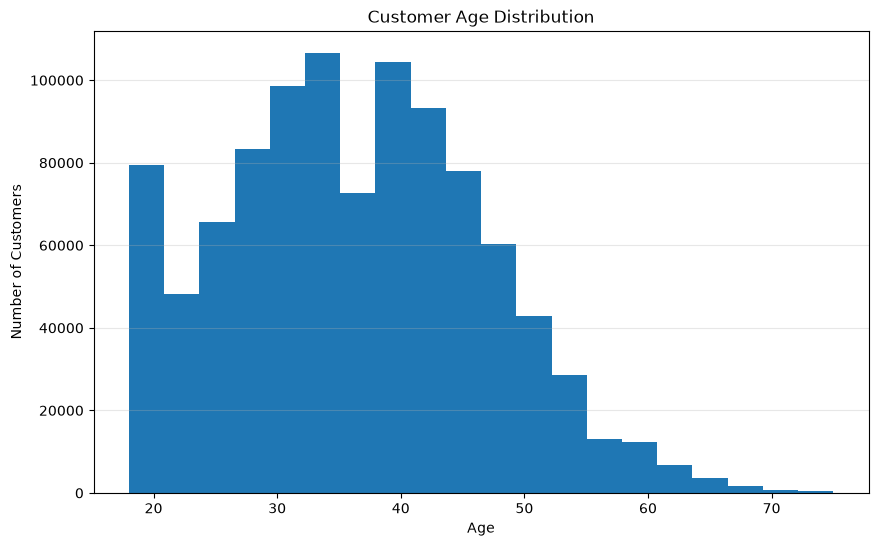

In [98]:
plt.figure(figsize=(10, 6))

plt.hist(
    customers["Age"].dropna(),
    bins=20
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [99]:
print(
    "Minimum Age:",
    customers["Age"].min()
)

print(
    "Maximum Age:",
    customers["Age"].max()
)

print(
    "Average Age:",
    round(customers["Age"].mean(), 2)
)

Minimum Age: 18
Maximum Age: 75
Average Age: 36.24


In [100]:
print(
    "Customers used in visualization:",
    customers["Age"].notna().sum()
)

print(
    "Missing Age values:",
    customers["Age"].isna().sum()
)

Customers used in visualization: 1000000
Missing Age values: 0


## 32. Visualization 2 — Income Distribution

This visualization shows the distribution of customer income
and helps understand the financial profile of customers.

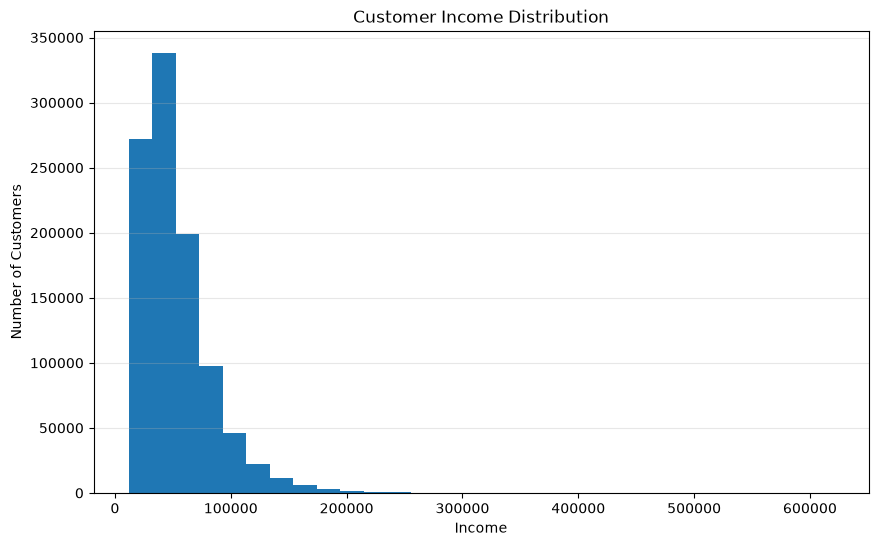

In [101]:
plt.figure(figsize=(10, 6))

plt.hist(
    customers["Income"].dropna(),
    bins=30
)

plt.title("Customer Income Distribution")
plt.xlabel("Income")
plt.ylabel("Number of Customers")

plt.grid(axis="y", alpha=0.3)

plt.show()

## 33. Visualization 3 — Customers by City

This visualization identifies cities with the largest
customer populations.

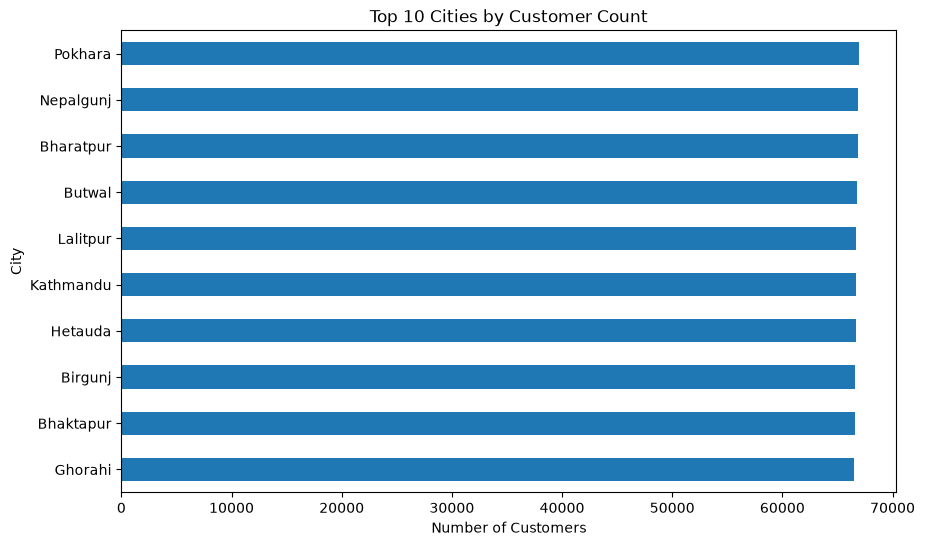

In [102]:
city_counts = (
    customers["City"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 6))

city_counts.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Cities by Customer Count")
plt.xlabel("Number of Customers")
plt.ylabel("City")

plt.show()

## 34. Visualization 4 — Monthly New Customers

This visualization shows how customer acquisition changes
over time.

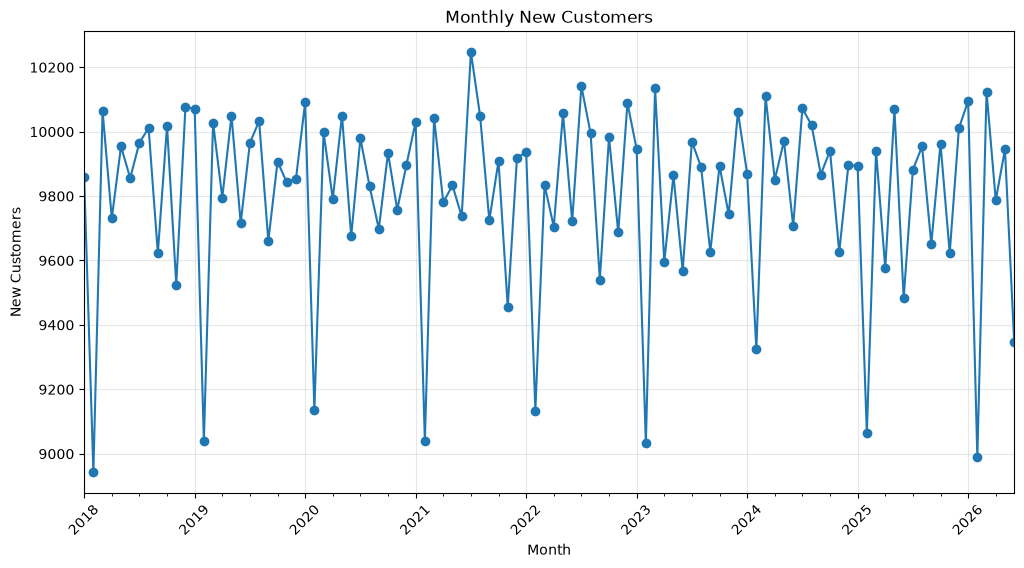

In [103]:
monthly_customers_plot = (
    customers
    .groupby(
        customers["JoinDate"].dt.to_period("M")
    )["CustomerID"]
    .nunique()
)

plt.figure(figsize=(12, 6))

monthly_customers_plot.plot(
    kind="line",
    marker="o"
)

plt.title("Monthly New Customers")
plt.xlabel("Month")
plt.ylabel("New Customers")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.show()

## 35. Visualization 5 — Account Balance by Type

This visualization compares total account balances across
different account types.

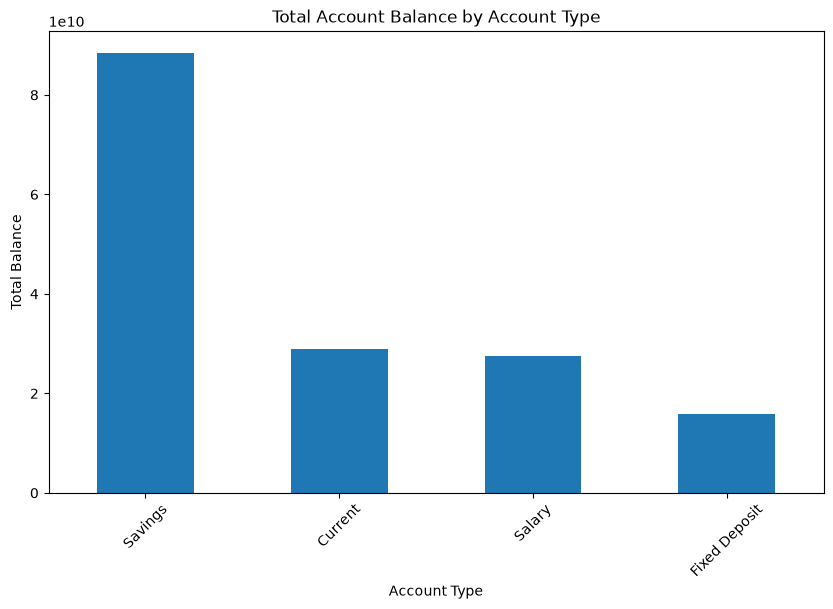

In [104]:
balance_type_plot = (
    accounts
    .groupby("AccountType")["Balance"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

balance_type_plot.plot(
    kind="bar"
)

plt.title("Total Account Balance by Account Type")
plt.xlabel("Account Type")
plt.ylabel("Total Balance")

plt.xticks(rotation=45)

plt.show()

## 36. Visualization 6 — Monthly Transaction Trend

This visualization shows changes in transaction activity
over time.

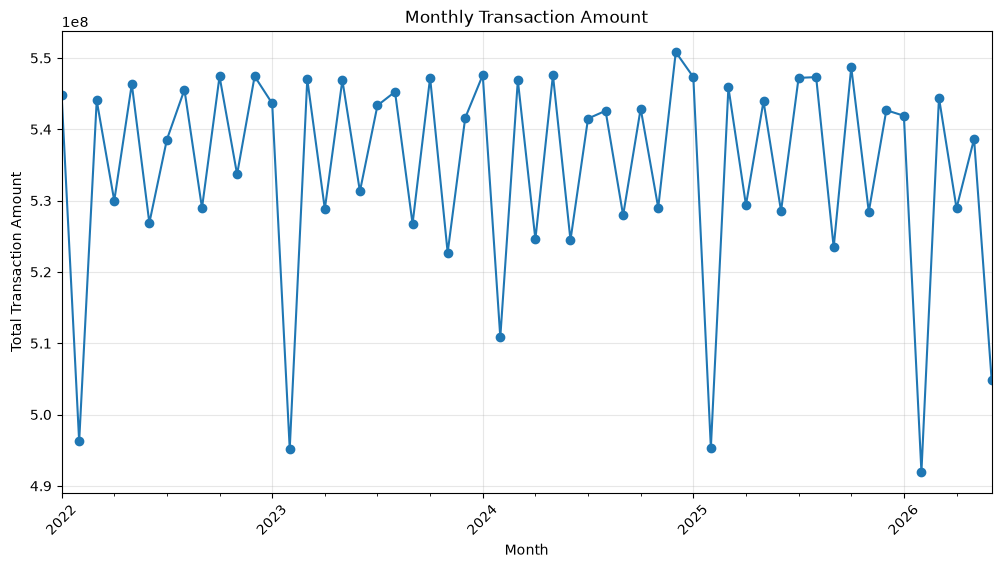

In [105]:
monthly_transaction_plot = (
    transactions
    .groupby(
        transactions["TransactionDate"].dt.to_period("M")
    )["Amount"]
    .sum()
)

plt.figure(figsize=(12, 6))

monthly_transaction_plot.plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Transaction Amount")
plt.xlabel("Month")
plt.ylabel("Total Transaction Amount")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.show()

## 37. Visualization 7 — Deposit vs Withdrawal

This visualization compares the transaction amounts associated
with deposits and withdrawals.

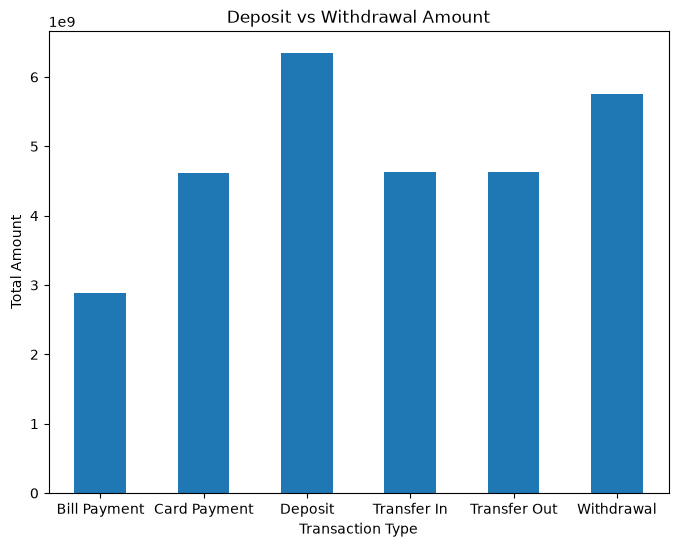

In [106]:
deposit_withdrawal = (
    transactions
    .groupby("TransactionType")["Amount"]
    .sum()
)

plt.figure(figsize=(8, 6))

deposit_withdrawal.plot(
    kind="bar"
)

plt.title("Deposit vs Withdrawal Amount")
plt.xlabel("Transaction Type")
plt.ylabel("Total Amount")

plt.xticks(rotation=0)

plt.show()

## 38. Visualization 8 — Transactions by Channel

This visualization identifies the most frequently used
transaction channels.

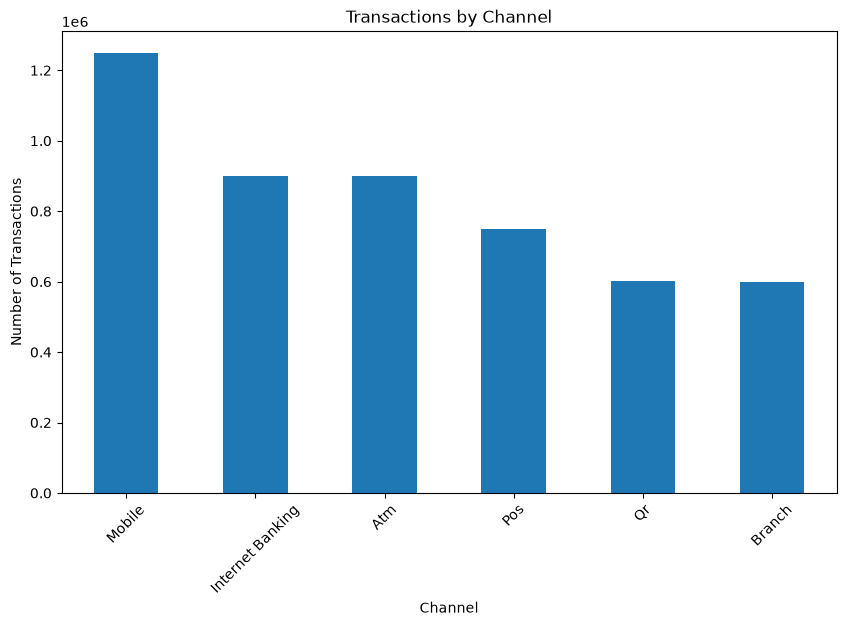

In [107]:
channel_counts = (
    transactions["Channel"]
    .value_counts()
)

plt.figure(figsize=(10, 6))

channel_counts.plot(
    kind="bar"
)

plt.title("Transactions by Channel")
plt.xlabel("Channel")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

## 39. Visualization 9 — Loan Amount Distribution

This visualization shows the distribution of loan amounts
across the loan portfolio.

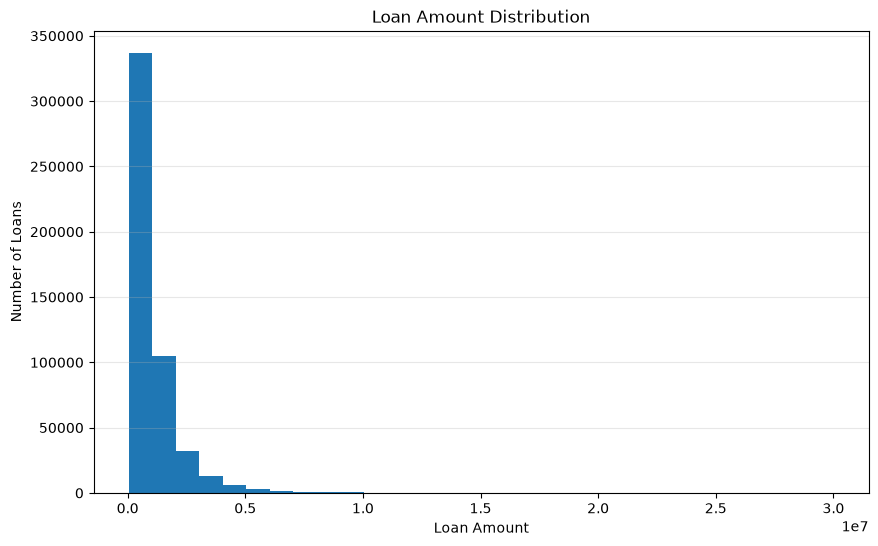

In [108]:
plt.figure(figsize=(10, 6))

plt.hist(
    loans["LoanAmount"].dropna(),
    bins=30
)

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Number of Loans")

plt.grid(axis="y", alpha=0.3)

plt.show()

## 40. Visualization 10 — Loans by Type

This visualization compares the number of loans across
different loan types.

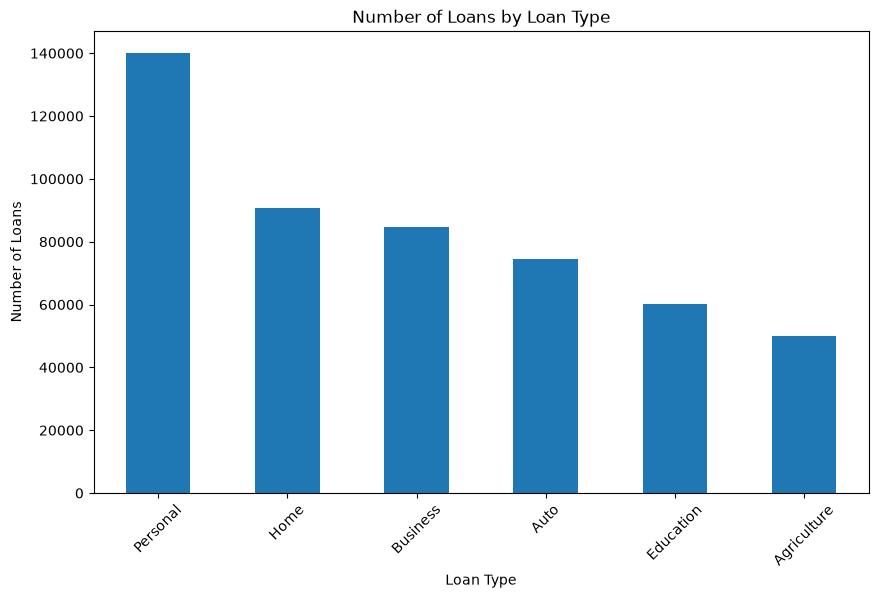

In [109]:
loan_type_counts = (
    loans["LoanType"]
    .value_counts()
)

plt.figure(figsize=(10, 6))

loan_type_counts.plot(
    kind="bar"
)

plt.title("Number of Loans by Loan Type")
plt.xlabel("Loan Type")
plt.ylabel("Number of Loans")

plt.xticks(rotation=45)

plt.show()

## 41. Visualization 11 — Loan Status Distribution

This visualization shows the distribution of loans according
to their current status.

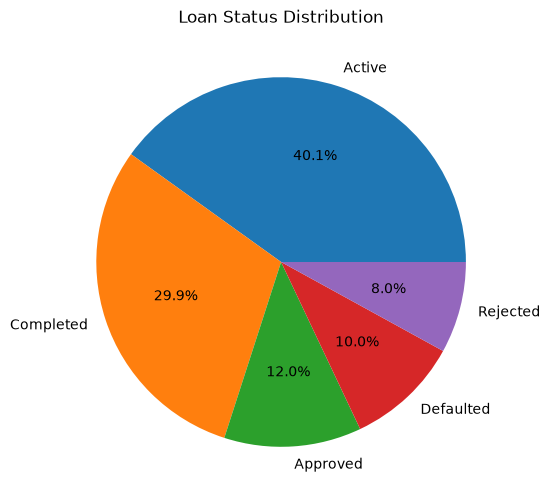

In [110]:
loan_status_counts = (
    loans["LoanStatus"]
    .value_counts()
)

plt.figure(figsize=(8, 6))

loan_status_counts.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Loan Status Distribution")
plt.ylabel("")

plt.show()

## 42. Visualization 12 — Income vs Loan Amount

This visualization examines the relationship between customer
income and loan amount.

The analysis helps determine whether higher-income customers
tend to have larger loans.

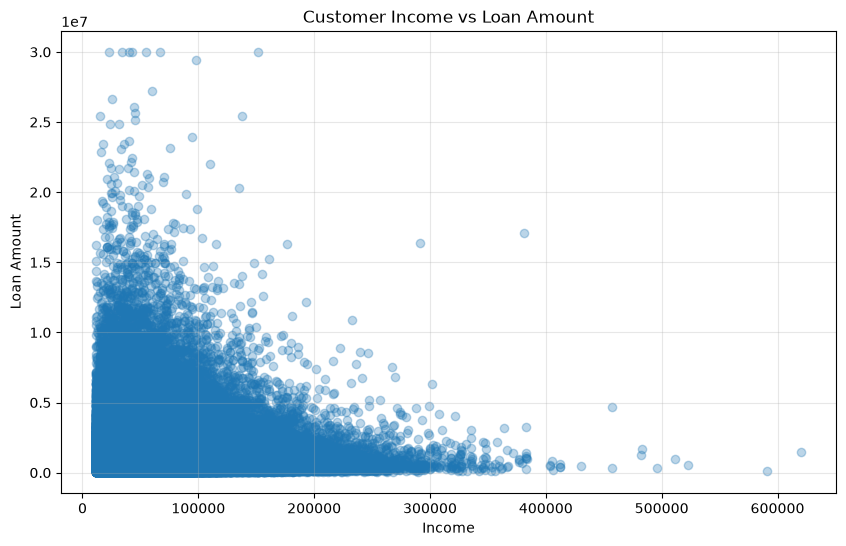

In [111]:
income_loan = loans.merge(
    customers[
        ["CustomerID", "Income"]
    ],
    on="CustomerID",
    how="left"
)

plt.figure(figsize=(10, 6))

plt.scatter(
    income_loan["Income"],
    income_loan["LoanAmount"],
    alpha=0.3
)

plt.title("Customer Income vs Loan Amount")
plt.xlabel("Income")
plt.ylabel("Loan Amount")

plt.grid(alpha=0.3)

plt.show()

## 43. Visualization 13 — Interest Rate vs Loan Amount

This visualization examines the relationship between interest
rate and loan amount.

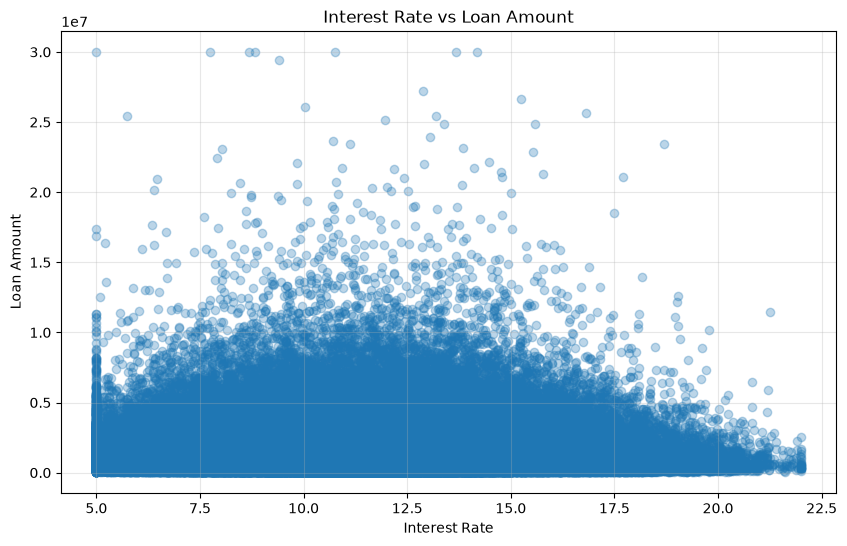

In [112]:
plt.figure(figsize=(10, 6))

plt.scatter(
    loans["InterestRate"],
    loans["LoanAmount"],
    alpha=0.3
)

plt.title("Interest Rate vs Loan Amount")
plt.xlabel("Interest Rate")
plt.ylabel("Loan Amount")

plt.grid(alpha=0.3)

plt.show()

## 44. Visualization 14 — Correlation Heatmap

A correlation heatmap helps identify relationships between
important numerical banking variables.

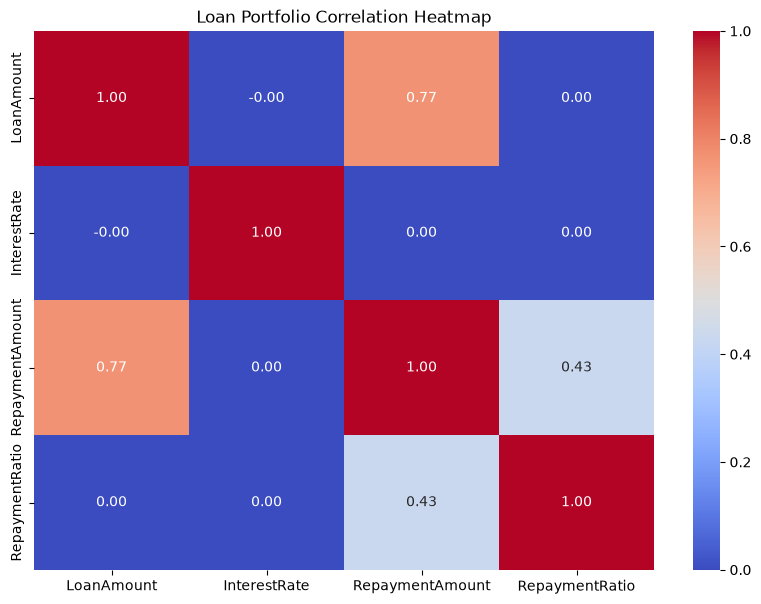

In [113]:
correlation_data = loans[
    [
        "LoanAmount",
        "InterestRate",
        "RepaymentAmount",
        "RepaymentRatio"
    ]
].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_data,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Loan Portfolio Correlation Heatmap")

plt.show()

## 45. Visualization 15 — Branch Performance

Branch performance will be evaluated using customer accounts,
deposits and loan activity.

This helps identify branches with strong deposit performance
and branches requiring management attention.

In [114]:
branch_account_analysis = (
    accounts
    .groupby("Branch")
    .agg(
        Customers=("CustomerID", "nunique"),
        Deposits=("Balance", "sum"),
        Accounts=("AccountID", "nunique")
    )
)

branch_loan_analysis = (
    accounts[
        ["CustomerID", "Branch"]
    ]
    .merge(
        loans[
            ["CustomerID", "LoanAmount"]
        ],
        on="CustomerID",
        how="inner"
    )
    .groupby("Branch")
    .agg(
        LoanAmount=("LoanAmount", "sum"),
        LoanCount=("LoanAmount", "count")
    )
)

branch_performance = (
    branch_account_analysis
    .join(branch_loan_analysis, how="left")
    .fillna(0)
)

branch_performance = branch_performance.sort_values(
    "Deposits",
    ascending=False
)

branch_performance.head(10)

,Customers,Deposits,Accounts,LoanAmount,LoanCount
Branch,,,,,
BR039,25723,3.274654e+09,26067,1.381864e+10,12983
BR047,25834,3.267667e+09,26177,1.384140e+10,13150
BR012,25836,3.265131e+09,26148,1.387611e+10,13286
BR027,25637,3.260816e+09,25972,1.342000e+10,12923
BR007,25580,3.258398e+09,25906,1.366450e+10,12979
BR018,26032,3.258341e+09,26384,1.379306e+10,13213
BR014,25750,3.241991e+09,26077,1.381112e+10,12980
BR037,25787,3.240730e+09,26175,1.357266e+10,13172
BR022,25811,3.236912e+09,26177,1.394336e+10,13244


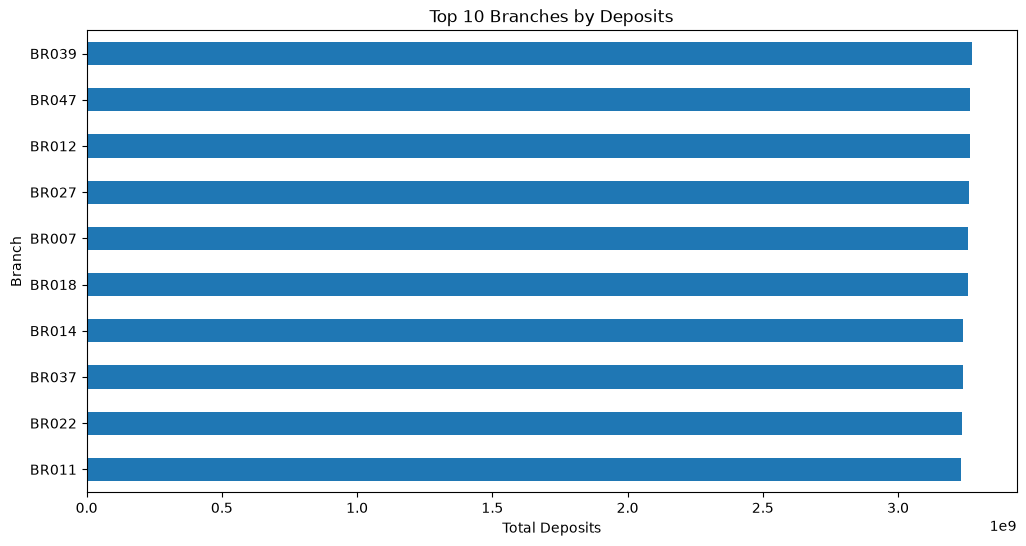

In [115]:
plt.figure(figsize=(12, 6))

branch_performance.head(10)[
    "Deposits"
].sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Branches by Deposits")
plt.xlabel("Total Deposits")
plt.ylabel("Branch")

plt.show()

# 46. Advanced Exploratory Data Analysis

In this section, we will perform advanced exploratory analysis
to understand deeper relationships between customers, accounts,
transactions, loans and branches.

The analysis will focus on:

1. Income vs Loan Amount
2. Interest Rate vs Repayment Performance
3. High Balance vs Low Transaction Activity
4. High Deposit vs Low Loan Activity Branches
5. Customer Risk Indicators
6. Rule-Based Risk Scoring

No Machine Learning model will be used.
The analysis is based on business rules and statistical relationships.

## 47. Higher Income vs Larger Loans

Business Question:

Do customers with higher income tend to take larger loans?

We will compare customer income with loan amount and calculate
the correlation between these two variables.

A positive correlation would indicate that higher income customers
generally tend to have larger loans.

In [116]:
income_loan_analysis = loans.merge(
    customers[["CustomerID", "Income"]],
    on="CustomerID",
    how="left"
)

income_loan_analysis.head()

,LoanID,CustomerID,LoanType,LoanAmount,InterestRate,LoanDate,LoanStatus,RepaymentAmount,RepaymentRatio,Income
0,1,974491,Home,652731.51,7.58,2021-06-22,Approved,266193.75,0.407815,54057.99
1,2,283305,Business,1439009.61,11.69,2024-07-26,Approved,834606.07,0.579986,45832.66
2,3,141195,Home,731314.16,11.99,2025-04-06,Completed,612129.88,0.837027,181384.31
3,4,385523,Auto,617687.75,16.17,2025-06-12,Approved,59459.23,0.096261,81902.80
4,5,449944,Education,273444.60,9.33,2020-05-03,Completed,181602.79,0.664130,83600.06


### Calculate Income and Loan Correlation

Correlation measures the strength of the relationship between
customer income and loan amount.

The value ranges from -1 to +1:

- +1 = Strong positive relationship
- 0 = No linear relationship
- -1 = Strong negative relationship

In [117]:
income_loan_correlation = income_loan_analysis[
    ["Income", "LoanAmount"]
].corr()

print("Income vs Loan Amount Correlation:")
print(income_loan_correlation)

Income vs Loan Amount Correlation:
              Income  LoanAmount
Income      1.000000    0.001551
LoanAmount  0.001551    1.000000


### Average Loan Amount by Income Group

Customers will be divided into income groups.

This helps us compare whether average loan amounts increase
as customer income increases.

In [118]:
income_loan_analysis["IncomeGroup"] = pd.qcut(
    income_loan_analysis["Income"],
    q=4,
    labels=["Low Income", "Lower-Middle Income",
            "Upper-Middle Income", "High Income"],
    duplicates="drop"
)

income_group_loan_analysis = (
    income_loan_analysis
    .groupby("IncomeGroup", observed=True)["LoanAmount"]
    .agg(["count", "mean", "median", "max"])
    .reset_index()
)

income_group_loan_analysis

,IncomeGroup,count,mean,median,max
0,Low Income,124884,1.044781e+06,694797.28,30000000.0
1,Lower-Middle Income,124885,1.050545e+06,700763.40,30000000.0
2,Upper-Middle Income,124881,1.046504e+06,699591.16,30000000.0
3,High Income,124883,1.053512e+06,700083.41,30000000.0


### Interpretation

The income-group comparison helps identify whether loan exposure
increases with customer income.

This is a descriptive business analysis and does not imply that
income directly causes higher loan amounts.

## 48. Interest Rate vs Repayment Performance

Business Question:

Does the interest rate have any relationship with repayment performance?

We will compare:

- Interest Rate
- Repayment Amount
- Repayment Ratio

Repayment Ratio is calculated as:

Repayment Ratio = Repayment Amount / Loan Amount

A lower repayment ratio indicates relatively lower repayment
against the original loan amount.

In [119]:
loans["RepaymentRatio"] = (
    loans["RepaymentAmount"] /
    loans["LoanAmount"]
)

loans[[
    "LoanID",
    "LoanAmount",
    "InterestRate",
    "RepaymentAmount",
    "RepaymentRatio"
]].head()

,LoanID,LoanAmount,InterestRate,RepaymentAmount,RepaymentRatio
0,1,652731.51,7.58,266193.75,0.407815
1,2,1439009.61,11.69,834606.07,0.579986
2,3,731314.16,11.99,612129.88,0.837027
3,4,617687.75,16.17,59459.23,0.096261
4,5,273444.60,9.33,181602.79,0.664130


### Calculate Interest Rate and Repayment Correlation

We will calculate the correlation between interest rate
and repayment ratio.

In [120]:
interest_repayment_correlation = loans[
    ["InterestRate", "RepaymentRatio"]
].corr()

print("Interest Rate vs Repayment Ratio Correlation:")
print(interest_repayment_correlation)

Interest Rate vs Repayment Ratio Correlation:
                InterestRate  RepaymentRatio
InterestRate         1.00000         0.00116
RepaymentRatio       0.00116         1.00000


### Create Interest Rate Groups

Interest rates will be divided into groups so that repayment
performance can be compared across different interest-rate levels.

In [121]:
loans["InterestRateGroup"] = pd.qcut(
    loans["InterestRate"],
    q=4,
    labels=[
        "Low Interest",
        "Lower-Medium Interest",
        "Upper-Medium Interest",
        "High Interest"
    ],
    duplicates="drop"
)

interest_rate_repayment = (
    loans
    .groupby("InterestRateGroup", observed=True)["RepaymentRatio"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

interest_rate_repayment

,InterestRateGroup,count,mean,median
0,Low Interest,125571,0.481416,0.482221
1,Lower-Medium Interest,124936,0.483435,0.482876
2,Upper-Medium Interest,124699,0.483452,0.483526
3,High Interest,124794,0.482436,0.484097


### Interpretation

The interest-rate analysis helps identify whether repayment
performance differs across interest-rate groups.

This result should be treated as an analytical relationship,
not as proof of causation.

## 49. High Balance but Low Transaction Activity

Business Question:

Which customers maintain high account balances but have
relatively low transaction activity?

These customers may represent an opportunity for:

- Customer engagement
- Product recommendations
- Investment products
- Relationship management

We will combine account balance information with transaction activity.

In [122]:
customer_balance = (
    accounts
    .groupby("CustomerID")["Balance"]
    .sum()
    .reset_index()
)

customer_balance.rename(
    columns={"Balance": "TotalBalance"},
    inplace=True
)

customer_balance.head()

,CustomerID,TotalBalance
0,1,117657.01
1,3,382973.65
2,4,235242.19
3,5,310347.48
4,7,72419.46


### Calculate Customer Transaction Activity

Transactions are connected to customers through AccountID.

Relationship:

Customers
    ↓
Accounts
    ↓
Transactions

We will first connect transactions with accounts and then
calculate customer-level transaction activity.

In [123]:
transaction_customer = transactions.merge(
    accounts[["AccountID", "CustomerID"]],
    on="AccountID",
    how="left"
)

customer_transaction_activity = (
    transaction_customer
    .groupby("CustomerID")
    .agg(
        TransactionCount=("TransactionID", "count"),
        TransactionAmount=("Amount", "sum")
    )
    .reset_index()
)

customer_transaction_activity.head()

,CustomerID,TransactionCount,TransactionAmount
0,1,10,48507.10
1,3,10,100973.13
2,4,8,97915.81
3,5,12,85956.84
4,7,5,18091.52


### Combine Balance and Transaction Activity

The two datasets will now be combined to identify customers
with high balances and low transaction activity.

In [124]:
customer_activity = customer_balance.merge(
    customer_transaction_activity,
    on="CustomerID",
    how="left"
)

customer_activity.head()

,CustomerID,TotalBalance,TransactionCount,TransactionAmount
0,1,117657.01,10.0,48507.10
1,3,382973.65,10.0,100973.13
2,4,235242.19,8.0,97915.81
3,5,310347.48,12.0,85956.84
4,7,72419.46,5.0,18091.52


### Define High Balance and Low Activity

We will use:

- 75th percentile of balance as the high-balance threshold
- 25th percentile of transaction count as the low-activity threshold

These thresholds are analytical rules for this project.
They are not official banking risk thresholds.

In [125]:
high_balance_threshold = customer_activity[
    "TotalBalance"
].quantile(0.75)

low_activity_threshold = customer_activity[
    "TransactionCount"
].quantile(0.25)

print("High Balance Threshold:", high_balance_threshold)
print("Low Transaction Activity Threshold:", low_activity_threshold)

High Balance Threshold: 285665.31999999995
Low Transaction Activity Threshold: 4.0


### Identify High-Balance Low-Activity Customers

In [126]:
high_balance_low_activity = customer_activity[
    (customer_activity["TotalBalance"] >= high_balance_threshold) &
    (customer_activity["TransactionCount"] <= low_activity_threshold)
].copy()

high_balance_low_activity = high_balance_low_activity.sort_values(
    "TotalBalance",
    ascending=False
)

high_balance_low_activity.head(20)

,CustomerID,TotalBalance,TransactionCount,TransactionAmount
369612,507739,5716013.09,4.0,45414.74
279075,383043,5333217.68,3.0,17628.94
552697,759337,5319000.04,3.0,18391.49
189398,259859,5262321.25,2.0,14104.65
500524,687646,5253692.84,3.0,15674.47
160817,220821,4709495.37,2.0,9458.22
4662,6387,4657938.71,3.0,12501.93
707229,972009,4569203.25,2.0,14875.53
263661,361749,4326217.02,4.0,12834.45
227964,312760,4257102.30,3.0,12398.12


### Count High-Balance Low-Activity Customers

In [127]:
high_balance_low_activity_count = (
    high_balance_low_activity["CustomerID"].nunique()
)

print(
    "High-Balance Low-Activity Customers:",
    high_balance_low_activity_count
)

High-Balance Low-Activity Customers: 28604


## 50. Branches with High Deposits but Low Loan Activity

Business Question:

Which branches have high customer deposits but relatively
low loan activity?

These branches may have strong deposit relationships but
lower lending activity.

Such branches may deserve additional product or lending
strategy analysis.

### Calculate Branch Deposit Performance

Account balances will be aggregated by branch.

This measures the total deposit/balance exposure associated
with each branch.

In [128]:
branch_deposits = (
    accounts
    .groupby("Branch")["Balance"]
    .sum()
    .reset_index()
)

branch_deposits.rename(
    columns={"Balance": "TotalDeposits"},
    inplace=True
)

branch_deposits.head()

,Branch,TotalDeposits
0,BR001,3.229943e+09
1,BR002,3.200864e+09
2,BR003,3.227174e+09
3,BR004,3.212397e+09
4,BR005,3.187892e+09


### Create Customer Primary Branch

A customer may have more than one account.

To avoid counting the same loan multiple times across branches,
we assign each customer to their first available branch in the
accounts dataset for this branch-level loan-activity analysis.

This is a project-specific analytical rule.

In [129]:
customer_primary_branch = (
    accounts[
        ["CustomerID", "Branch"]
    ]
    .drop_duplicates("CustomerID")
)

customer_primary_branch.head()

,CustomerID,Branch
0,436452,BR018
1,214285,BR046
2,279723,BR001
3,732562,BR020
4,907096,BR003


### Calculate Loan Activity by Branch

Loans are connected to branches through:

Customers → Accounts → Branch

We will count the number of customers with loans in each
primary branch.

In [130]:
loan_branch_activity = loans[
    ["LoanID", "CustomerID", "LoanAmount"]
].merge(
    customer_primary_branch,
    on="CustomerID",
    how="left"
)

branch_loan_activity = (
    loan_branch_activity
    .groupby("Branch")
    .agg(
        LoanCustomerCount=("CustomerID", "nunique"),
        LoanCount=("LoanID", "count"),
        TotalLoanAmount=("LoanAmount", "sum")
    )
    .reset_index()
)

branch_loan_activity.head()

,Branch,LoanCustomerCount,LoanCount,TotalLoanAmount
0,BR001,5825,7399,7.789107e+09
1,BR002,5729,7285,7.703998e+09
2,BR003,5739,7288,7.641496e+09
3,BR004,5896,7589,7.981240e+09
4,BR005,5726,7209,7.614374e+09


### Combine Branch Deposits and Loan Activity

In [131]:
branch_deposit_loan = branch_deposits.merge(
    branch_loan_activity,
    on="Branch",
    how="left"
)

branch_deposit_loan[
    ["LoanCustomerCount", "LoanCount", "TotalLoanAmount"]
] = branch_deposit_loan[
    ["LoanCustomerCount", "LoanCount", "TotalLoanAmount"]
].fillna(0)

branch_deposit_loan.head()

,Branch,TotalDeposits,LoanCustomerCount,LoanCount,TotalLoanAmount
0,BR001,3.229943e+09,5825,7399,7.789107e+09
1,BR002,3.200864e+09,5729,7285,7.703998e+09
2,BR003,3.227174e+09,5739,7288,7.641496e+09
3,BR004,3.212397e+09,5896,7589,7.981240e+09
4,BR005,3.187892e+09,5726,7209,7.614374e+09


### Define High Deposit and Low Loan Activity

We will use:

- 75th percentile of deposits as high deposits
- 25th percentile of loan customer count as low loan activity

These thresholds are analytical rules created for this project.

In [132]:
high_deposit_threshold = branch_deposit_loan[
    "TotalDeposits"
].quantile(0.75)

low_loan_activity_threshold = branch_deposit_loan[
    "LoanCustomerCount"
].quantile(0.25)

print("High Deposit Threshold:", high_deposit_threshold)
print(
    "Low Loan Activity Threshold:",
    low_loan_activity_threshold
)

High Deposit Threshold: 3230925219.0375
Low Loan Activity Threshold: 5662.5


### Identify High-Deposit Low-Loan-Activity Branches

In [133]:
high_deposit_threshold = branch_deposit_loan["TotalDeposits"].quantile(0.75)
low_loan_activity_threshold = branch_deposit_loan["LoanCustomerCount"].quantile(0.50)

high_deposit_low_loan = branch_deposit_loan[
    (branch_deposit_loan["TotalDeposits"] >= high_deposit_threshold) &
    (branch_deposit_loan["LoanCustomerCount"] <= low_loan_activity_threshold)
].copy()

high_deposit_low_loan = high_deposit_low_loan.sort_values(
    "TotalDeposits",
    ascending=False
)

high_deposit_low_loan

,Branch,TotalDeposits,LoanCustomerCount,LoanCount,TotalLoanAmount
26,BR027,3.260816e+09,5687,7202,7.471717e+09
6,BR007,3.258398e+09,5685,7274,7.574709e+09
39,BR040,3.231646e+09,5710,7287,7.675485e+09


## 51. Customer Risk Indicators

The project requires identifying important customer-level
risk indicators.

The following indicators will be analyzed:

1. High loan amount
2. Low customer income
3. Poor repayment performance
4. Multiple loans
5. High outstanding loan balance

These indicators will be used for analytical segmentation.

Important:

This is NOT a machine-learning credit-risk model.

It is a rule-based business analysis created for this project.

In [136]:
# Create customer-level risk analysis dataset

customer_balance = (
    accounts
    .groupby("CustomerID")["Balance"]
    .sum()
    .reset_index()
)

customer_balance.rename(
    columns={"Balance": "TotalBalance"},
    inplace=True
)

customer_loan_summary = (
    loans
    .groupby("CustomerID")
    .agg(
        LoanCount=("LoanID", "count"),
        TotalLoanAmount=("LoanAmount", "sum"),
        TotalRepaymentAmount=("RepaymentAmount", "sum"),
        AverageInterestRate=("InterestRate", "mean"),
        AverageRepaymentRatio=("RepaymentRatio", "mean")
    )
    .reset_index()
)

customer_loan_summary["EstimatedOutstandingAmount"] = (
    customer_loan_summary["TotalLoanAmount"]
    - customer_loan_summary["TotalRepaymentAmount"]
).clip(lower=0)

customer_risk = customers[
    ["CustomerID", "Income"]
].merge(
    customer_balance,
    on="CustomerID",
    how="left"
).merge(
    customer_loan_summary,
    on="CustomerID",
    how="left"
)

customer_risk["LoanCount"] = customer_risk["LoanCount"].fillna(0)
customer_risk["TotalLoanAmount"] = customer_risk["TotalLoanAmount"].fillna(0)
customer_risk["TotalRepaymentAmount"] = customer_risk["TotalRepaymentAmount"].fillna(0)
customer_risk["EstimatedOutstandingAmount"] = customer_risk[
    "EstimatedOutstandingAmount"
].fillna(0)

customer_risk["AverageInterestRate"] = customer_risk[
    "AverageInterestRate"
].fillna(0)

customer_risk["AverageRepaymentRatio"] = customer_risk[
    "AverageRepaymentRatio"
].fillna(0)

customer_risk.head()

,CustomerID,Income,TotalBalance,LoanCount,TotalLoanAmount,TotalRepaymentAmount,AverageInterestRate,AverageRepaymentRatio,EstimatedOutstandingAmount
0,1,100160.69,117657.01,1.0,1379561.94,489183.3,13.57,0.354593,890378.64
1,2,48799.82,NaN,0.0,0.00,0.0,0.00,0.000000,0.00
2,3,116220.01,382973.65,0.0,0.00,0.0,0.00,0.000000,0.00
3,4,26244.75,235242.19,0.0,0.00,0.0,0.00,0.000000,0.00
4,5,57600.26,310347.48,0.0,0.00,0.0,0.00,0.000000,0.00


In [137]:
high_loan_threshold = customer_risk[
    "TotalLoanAmount"
].quantile(0.75)

low_income_threshold = customer_risk[
    "Income"
].quantile(0.25)

loan_customers = customer_risk[
    customer_risk["LoanCount"] > 0
]

poor_repayment_threshold = loan_customers[
    "AverageRepaymentRatio"
].quantile(0.25)

high_outstanding_threshold = customer_risk[
    "EstimatedOutstandingAmount"
].quantile(0.75)

In [138]:
customer_risk["HighLoanAmount"] = (
    customer_risk["TotalLoanAmount"] >= high_loan_threshold
)

customer_risk["LowIncome"] = (
    customer_risk["Income"] <= low_income_threshold
)

customer_risk["PoorRepayment"] = (
    (customer_risk["LoanCount"] > 0) &
    (
        customer_risk["AverageRepaymentRatio"]
        <= poor_repayment_threshold
    )
)

customer_risk["MultipleLoans"] = (
    customer_risk["LoanCount"] >= 2
)

customer_risk["HighOutstandingBalance"] = (
    customer_risk["EstimatedOutstandingAmount"]
    >= high_outstanding_threshold
)

In [139]:
risk_indicators = pd.DataFrame({
    "Risk Indicator": [
        "High Loan Amount",
        "Low Income",
        "Poor Repayment",
        "Multiple Loans",
        "High Outstanding Balance"
    ],
    "Customer Count": [
        customer_risk["HighLoanAmount"].sum(),
        customer_risk["LowIncome"].sum(),
        customer_risk["PoorRepayment"].sum(),
        customer_risk["MultipleLoans"].sum(),
        customer_risk["HighOutstandingBalance"].sum()
    ]
})

risk_indicators

,Risk Indicator,Customer Count
0,High Loan Amount,250000
1,Low Income,249751
2,Poor Repayment,98278
3,Multiple Loans,90505
4,High Outstanding Balance,250000


## 52. Customer Loan Summary

We will create one customer-level table containing:

- Number of loans
- Total loan amount
- Total repayment amount
- Estimated outstanding amount
- Average interest rate
- Average repayment ratioD

In [141]:
customer_loan_summary = (
    loans
    .groupby("CustomerID")
    .agg(
        LoanCount=("LoanID", "count"),
        TotalLoanAmount=("LoanAmount", "sum"),
        TotalRepaymentAmount=("RepaymentAmount", "sum"),
        AverageInterestRate=("InterestRate", "mean"),
        AverageRepaymentRatio=("RepaymentRatio", "mean")
    )
    .reset_index()
)

customer_loan_summary.head()

,CustomerID,LoanCount,TotalLoanAmount,TotalRepaymentAmount,AverageInterestRate,AverageRepaymentRatio
0,1,1,1379561.94,489183.30,13.570000,0.354593
1,7,2,8463415.56,5706711.08,13.155000,0.683686
2,11,1,2744317.20,653183.01,9.180000,0.238013
3,14,3,4844435.70,1447842.99,9.456667,0.341593
4,15,1,894168.20,687464.20,7.330000,0.768831


### Calculate Estimated Outstanding Amount

Estimated Outstanding Amount is calculated as:

Loan Amount - Repayment Amount

Negative values are replaced with zero.

This is a simplified project-level indicator and should not be
treated as an official banking accounting measure.

In [142]:
customer_loan_summary["EstimatedOutstandingAmount"] = (
    customer_loan_summary["TotalLoanAmount"] -
    customer_loan_summary["TotalRepaymentAmount"]
).clip(lower=0)

customer_loan_summary.head()

,CustomerID,LoanCount,TotalLoanAmount,TotalRepaymentAmount,AverageInterestRate,AverageRepaymentRatio,EstimatedOutstandingAmount
0,1,1,1379561.94,489183.30,13.570000,0.354593,890378.64
1,7,2,8463415.56,5706711.08,13.155000,0.683686,2756704.48
2,11,1,2744317.20,653183.01,9.180000,0.238013,2091134.19
3,14,3,4844435.70,1447842.99,9.456667,0.341593,3396592.71
4,15,1,894168.20,687464.20,7.330000,0.768831,206704.00


## 53. Combine Customer Risk Data

We will combine:

- Customer income
- Account balance
- Loan information

into one customer-level analytical dataset.

In [143]:
customer_risk = customers[
    ["CustomerID", "Income"]
].merge(
    customer_balance,
    on="CustomerID",
    how="left"
).merge(
    customer_loan_summary,
    on="CustomerID",
    how="left"
)

customer_risk.head()

,CustomerID,Income,TotalBalance,LoanCount,TotalLoanAmount,TotalRepaymentAmount,AverageInterestRate,AverageRepaymentRatio,EstimatedOutstandingAmount
0,1,100160.69,117657.01,1.0,1379561.94,489183.3,13.57,0.354593,890378.64
1,2,48799.82,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,116220.01,382973.65,NaN,NaN,NaN,NaN,NaN,NaN
3,4,26244.75,235242.19,NaN,NaN,NaN,NaN,NaN,NaN
4,5,57600.26,310347.48,NaN,NaN,NaN,NaN,NaN,NaN


### Handle Customers Without Loans

Not every customer necessarily has a loan.

For customers without loans:

- LoanCount = 0
- LoanAmount = 0
- RepaymentAmount = 0
- OutstandingAmount = 0

This allows us to perform customer-level analysis consistently.

In [144]:
loan_columns = [
    "LoanCount",
    "TotalLoanAmount",
    "TotalRepaymentAmount",
    "EstimatedOutstandingAmount"
]

customer_risk[loan_columns] = customer_risk[
    loan_columns
].fillna(0)

customer_risk["AverageInterestRate"] = (
    customer_risk["AverageInterestRate"].fillna(0)
)

customer_risk["AverageRepaymentRatio"] = (
    customer_risk["AverageRepaymentRatio"].fillna(0)
)

customer_risk.head()

,CustomerID,Income,TotalBalance,LoanCount,TotalLoanAmount,TotalRepaymentAmount,AverageInterestRate,AverageRepaymentRatio,EstimatedOutstandingAmount
0,1,100160.69,117657.01,1.0,1379561.94,489183.3,13.57,0.354593,890378.64
1,2,48799.82,NaN,0.0,0.00,0.0,0.00,0.000000,0.00
2,3,116220.01,382973.65,0.0,0.00,0.0,0.00,0.000000,0.00
3,4,26244.75,235242.19,0.0,0.00,0.0,0.00,0.000000,0.00
4,5,57600.26,310347.48,0.0,0.00,0.0,0.00,0.000000,0.00


## 54. Risk Indicator Thresholds

We will create analytical thresholds using customer-level
distributions.

Thresholds:

- High Loan Exposure = 75th percentile
- Low Income = 25th percentile
- Poor Repayment = 25th percentile among customers with loans
- Multiple Loans = 2 or more loans
- High Outstanding Amount = 75th percentile

These thresholds are created specifically for exploratory
analysis and are not official bank credit-risk policies.

In [145]:
high_loan_threshold = customer_risk[
    "TotalLoanAmount"
].quantile(0.75)

low_income_threshold = customer_risk[
    "Income"
].quantile(0.25)

loan_customers = customer_risk[
    customer_risk["LoanCount"] > 0
]

poor_repayment_threshold = loan_customers[
    "AverageRepaymentRatio"
].quantile(0.25)

high_outstanding_threshold = customer_risk[
    "EstimatedOutstandingAmount"
].quantile(0.75)

print("High Loan Threshold:", high_loan_threshold)
print("Low Income Threshold:", low_income_threshold)
print(
    "Poor Repayment Threshold:",
    poor_repayment_threshold
)
print(
    "High Outstanding Threshold:",
    high_outstanding_threshold
)

High Loan Threshold: 628938.5700000001
Low Income Threshold: 31068.17
Poor Repayment Threshold: 0.25681758897036067
High Outstanding Threshold: 256770.99500000002


## 55. Create Individual Risk Indicators

Each customer will be evaluated against the following
business indicators:

High Loan Amount:
    Total loan amount is at or above the 75th percentile.

Low Income:
    Income is at or below the 25th percentile.

Poor Repayment:
    Average repayment ratio is at or below the lower quartile
    among customers who have loans.

Multiple Loans:
    Customer has two or more loans.

High Outstanding Balance:
    Estimated outstanding amount is at or above the
    75th percentile.

In [146]:
customer_risk["HighLoanAmount"] = (
    customer_risk["TotalLoanAmount"] >= high_loan_threshold
)

customer_risk["LowIncome"] = (
    customer_risk["Income"] <= low_income_threshold
)

customer_risk["PoorRepayment"] = (
    (customer_risk["LoanCount"] > 0) &
    (
        customer_risk["AverageRepaymentRatio"]
        <= poor_repayment_threshold
    )
)

customer_risk["MultipleLoans"] = (
    customer_risk["LoanCount"] >= 2
)

customer_risk["HighOutstandingBalance"] = (
    customer_risk["EstimatedOutstandingAmount"]
    >= high_outstanding_threshold
)

customer_risk.head()

,CustomerID,Income,TotalBalance,LoanCount,TotalLoanAmount,TotalRepaymentAmount,AverageInterestRate,AverageRepaymentRatio,EstimatedOutstandingAmount,HighLoanAmount,LowIncome,PoorRepayment,MultipleLoans,HighOutstandingBalance
0,1,100160.69,117657.01,1.0,1379561.94,489183.3,13.57,0.354593,890378.64,True,False,False,False,True
1,2,48799.82,NaN,0.0,0.00,0.0,0.00,0.000000,0.00,False,False,False,False,False
2,3,116220.01,382973.65,0.0,0.00,0.0,0.00,0.000000,0.00,False,False,False,False,False
3,4,26244.75,235242.19,0.0,0.00,0.0,0.00,0.000000,0.00,False,True,False,False,False
4,5,57600.26,310347.48,0.0,0.00,0.0,0.00,0.000000,0.00,False,False,False,False,False


## 56. Count Customers by Risk Indicator

We will count how many customers satisfy each
individual risk indicator.

This helps management understand which indicators
are most common in the customer portfolio.

In [147]:
risk_indicator_counts = {
    "High Loan Amount": customer_risk["HighLoanAmount"].sum(),
    "Low Income": customer_risk["LowIncome"].sum(),
    "Poor Repayment": customer_risk["PoorRepayment"].sum(),
    "Multiple Loans": customer_risk["MultipleLoans"].sum(),
    "High Outstanding Balance": customer_risk[
        "HighOutstandingBalance"
    ].sum()
}

risk_indicator_counts

{'High Loan Amount': np.int64(250000),
 'Low Income': np.int64(249751),
 'Poor Repayment': np.int64(98278),
 'Multiple Loans': np.int64(90505),
 'High Outstanding Balance': np.int64(250000)}

### Convert Risk Indicator Counts to DataFrame

In [148]:
risk_indicator_summary = pd.DataFrame(
    list(risk_indicator_counts.items()),
    columns=["RiskIndicator", "CustomerCount"]
)

risk_indicator_summary = risk_indicator_summary.sort_values(
    "CustomerCount",
    ascending=False
)

risk_indicator_summary

,RiskIndicator,CustomerCount
0,High Loan Amount,250000
4,High Outstanding Balance,250000
1,Low Income,249751
2,Poor Repayment,98278
3,Multiple Loans,90505


## 57. Rule-Based Customer Risk Score

A simple rule-based score will now be created.

Scoring rules:

- High Loan Amount = +2
- Low Income = +2
- Poor Repayment = +2
- Multiple Loans = +1
- High Outstanding Balance = +1

Maximum possible score = 8.

Risk Categories:

0–2   → Low Risk Indicator
3–4   → Medium Risk Indicator
5–8   → High Risk Indicator

This score is created only for project-level analytical
segmentation. It is NOT a validated credit score.

In [149]:
customer_risk["RiskScore"] = (
    customer_risk["HighLoanAmount"].astype(int) * 2
    + customer_risk["LowIncome"].astype(int) * 2
    + customer_risk["PoorRepayment"].astype(int) * 2
    + customer_risk["MultipleLoans"].astype(int)
    + customer_risk["HighOutstandingBalance"].astype(int)
)

customer_risk[[
    "CustomerID",
    "RiskScore",
    "HighLoanAmount",
    "LowIncome",
    "PoorRepayment",
    "MultipleLoans",
    "HighOutstandingBalance"
]].head()

,CustomerID,RiskScore,HighLoanAmount,LowIncome,PoorRepayment,MultipleLoans,HighOutstandingBalance
0,1,3,True,False,False,False,True
1,2,0,False,False,False,False,False
2,3,0,False,False,False,False,False
3,4,2,False,True,False,False,False
4,5,0,False,False,False,False,False


## 58. Customer Risk Category

Customers will be grouped into three analytical categories:

Low Risk Indicator:
    Risk Score from 0 to 2

Medium Risk Indicator:
    Risk Score from 3 to 4

High Risk Indicator:
    Risk Score from 5 to 8

In [150]:
def classify_risk(score):
    if score >= 5:
        return "High Risk Indicator"
    elif score >= 3:
        return "Medium Risk Indicator"
    else:
        return "Low Risk Indicator"


customer_risk["RiskCategory"] = (
    customer_risk["RiskScore"]
    .apply(classify_risk)
)

customer_risk[[
    "CustomerID",
    "RiskScore",
    "RiskCategory"
]].head(20)

,CustomerID,RiskScore,RiskCategory
0,1,3,Medium Risk Indicator
1,2,0,Low Risk Indicator
2,3,0,Low Risk Indicator
3,4,2,Low Risk Indicator
4,5,0,Low Risk Indicator
5,6,0,Low Risk Indicator
6,7,4,Medium Risk Indicator
7,8,0,Low Risk Indicator
8,9,0,Low Risk Indicator
9,10,2,Low Risk Indicator


## 59. Risk Category Distribution

We will calculate the number of customers in each
rule-based risk category.

This gives an overall view of the customer portfolio
from the perspective of the defined analytical indicators.

In [151]:
risk_category_distribution = (
    customer_risk["RiskCategory"]
    .value_counts()
    .reset_index()
)

risk_category_distribution.columns = [
    "RiskCategory",
    "CustomerCount"
]

risk_category_distribution

,RiskCategory,CustomerCount
0,Low Risk Indicator,742399
1,Medium Risk Indicator,153537
2,High Risk Indicator,104064


### Risk Category Percentage

We will also calculate the percentage of customers
in each risk category.

In [152]:
risk_category_distribution["Percentage"] = (
    risk_category_distribution["CustomerCount"]
    / risk_category_distribution["CustomerCount"].sum()
    * 100
)

risk_category_distribution

,RiskCategory,CustomerCount,Percentage
0,Low Risk Indicator,742399,74.2399
1,Medium Risk Indicator,153537,15.3537
2,High Risk Indicator,104064,10.4064


## 60. High-Risk Customer Analysis

We will identify customers with a high rule-based risk indicator.

These customers have multiple risk indicators according
to the project-specific scoring system.

The output can later support management attention areas.

In [153]:
high_risk_customers = customer_risk[
    customer_risk["RiskCategory"] == "High Risk Indicator"
].copy()

high_risk_customers = high_risk_customers.sort_values(
    "RiskScore",
    ascending=False
)

high_risk_customers.head(20)

,CustomerID,Income,TotalBalance,LoanCount,TotalLoanAmount,TotalRepaymentAmount,AverageInterestRate,AverageRepaymentRatio,EstimatedOutstandingAmount,HighLoanAmount,LowIncome,PoorRepayment,MultipleLoans,HighOutstandingBalance,RiskScore,RiskCategory
511158,511159,21182.30,109230.53,2.0,4530383.64,907315.53,12.245000,0.190398,3623068.11,True,True,True,True,True,8,High Risk Indicator
361573,361574,28429.26,9938.24,3.0,1836376.49,455923.47,10.403333,0.147398,1380453.02,True,True,True,True,True,8,High Risk Indicator
945491,945492,22479.26,98858.02,2.0,2591621.09,392046.84,13.100000,0.222129,2199574.25,True,True,True,True,True,8,High Risk Indicator
585334,585335,21060.78,80460.44,2.0,881658.78,184897.34,12.795000,0.252145,696761.44,True,True,True,True,True,8,High Risk Indicator
540420,540421,23018.57,126539.88,2.0,6814814.56,3409130.53,8.310000,0.252987,3405684.03,True,True,True,True,True,8,High Risk Indicator
433380,433381,20537.98,401182.98,2.0,1748314.42,64534.81,9.870000,0.240086,1683779.61,True,True,True,True,True,8,High Risk Indicator
433387,433388,22972.95,49397.23,2.0,2945054.72,554892.81,11.160000,0.141185,2390161.91,True,True,True,True,True,8,High Risk Indicator
958310,958311,27438.44,21808.05,2.0,3015361.58,323604.57,13.325000,0.177179,2691757.01,True,True,True,True,True,8,High Risk Indicator
15679,15680,26029.96,147152.86,2.0,2958977.64,709113.74,12.310000,0.237536,2249863.90,True,True,True,True,True,8,High Risk Indicator
389763,389764,30085.48,13343.88,2.0,655239.39,25633.78,14.095000,0.159109,629605.61,True,True,True,True,True,8,High Risk Indicator


### Top High-Risk Customers by Loan Exposure

We will rank high-risk customers by total loan amount.

In [154]:
top_high_risk_customers = high_risk_customers.sort_values(
    ["TotalLoanAmount", "RiskScore"],
    ascending=[False, False]
)

top_high_risk_customers[
    [
        "CustomerID",
        "Income",
        "TotalLoanAmount",
        "LoanCount",
        "AverageRepaymentRatio",
        "EstimatedOutstandingAmount",
        "RiskScore",
        "RiskCategory"
    ]
].head(20)

,CustomerID,Income,TotalLoanAmount,LoanCount,AverageRepaymentRatio,EstimatedOutstandingAmount,RiskScore,RiskCategory
252801,252802,23262.00,34752151.04,3.0,0.462894,29346506.22,6,High Risk Indicator
513480,513481,42364.98,30716706.62,2.0,0.182370,19774498.59,6,High Risk Indicator
108275,108276,40110.42,30561316.02,2.0,0.231697,19762764.52,6,High Risk Indicator
978219,978220,54923.81,30000000.00,1.0,0.057915,28262552.69,5,High Risk Indicator
926679,926680,59714.97,27239171.65,1.0,0.097734,24576981.78,5,High Risk Indicator
498040,498041,25900.40,26668153.84,1.0,0.159485,22414988.97,7,High Risk Indicator
344316,344317,44569.05,26096777.85,1.0,0.232399,20031920.84,5,High Risk Indicator
17794,17795,45215.04,25818129.26,2.0,0.042946,23657865.91,6,High Risk Indicator
170686,170687,15541.32,25444162.30,1.0,0.492698,12907878.13,5,High Risk Indicator
42282,42283,23371.56,24867295.35,1.0,0.000000,24867295.35,7,High Risk Indicator


# Advanced EDA Validation

Before completing Week 2, we will validate the major
advanced analysis outputs.

Validation checks:

1. Income-loan correlation exists
2. Repayment ratio exists
3. Customer risk table was created
4. Risk score contains valid values
5. Risk categories are valid
6. High-balance low-activity analysis exists
7. High-deposit low-loan branch analysis exists

In [155]:
print("Income vs Loan Correlation:")
print(
    income_loan_analysis[
        ["Income", "LoanAmount"]
    ].corr().iloc[0, 1]
)

print("\nInterest Rate vs Repayment Correlation:")
print(
    loans[
        ["InterestRate", "RepaymentRatio"]
    ].corr().iloc[0, 1]
)

print("\nCustomer Risk Rows:", customer_risk.shape[0])

print(
    "\nRisk Score Minimum:",
    customer_risk["RiskScore"].min()
)

print(
    "Risk Score Maximum:",
    customer_risk["RiskScore"].max()
)

print(
    "\nHigh-Balance Low-Activity Customers:",
    high_balance_low_activity_count
)

print(
    "High-Deposit Low-Loan Branches:",
    high_deposit_low_loan.shape[0]
)

Income vs Loan Correlation:
0.0015507542162480738

Interest Rate vs Repayment Correlation:
0.0011599363846098026

Customer Risk Rows: 1000000

Risk Score Minimum: 0
Risk Score Maximum: 8

High-Balance Low-Activity Customers: 28604
High-Deposit Low-Loan Branches: 3


## Risk Score Validation

The maximum possible score is 8.

Therefore, every customer risk score must be between 0 and 8.

In [156]:
risk_score_valid = customer_risk[
    "RiskScore"
].between(0, 8).all()

print("Risk Score Validation:", risk_score_valid)

Risk Score Validation: True


## Risk Category Validation

Only the following categories are allowed:

- Low Risk Indicator
- Medium Risk Indicator
- High Risk Indicator

In [157]:
valid_categories = {
    "Low Risk Indicator",
    "Medium Risk Indicator",
    "High Risk Indicator"
}

category_validation = set(
    customer_risk["RiskCategory"].dropna().unique()
).issubset(valid_categories)

print("Risk Category Validation:", category_validation)

Risk Category Validation: True


# Week 2 Final Validation

The Exploratory Data Analysis phase is now validated.

The analysis covered:

### Customer Analysis
- Total customers
- Average age
- Average income
- Top cities
- Occupation analysis
- Monthly customer growth
- Customers with loans

### Account Analysis
- Total deposits
- Average balance
- Account type analysis
- Branch deposits
- Top customers by balance

### Transaction Analysis
- Total transaction amount
- Transaction count
- Deposits vs withdrawals
- Monthly transaction trends
- Transaction channels

### Loan Analysis
- Total loans
- Total loan amount
- Average loan amount
- Loan type analysis
- Loan city analysis
- Loan status
- Repayment performance

### Advanced EDA
- Income vs loan relationship
- Interest rate vs repayment
- High balance with low transaction activity
- High deposits with low loan activity
- Customer risk indicators
- Rule-based risk scoring

No Machine Learning or AI was used.

In [159]:
# ========================================
# WEEK 2 EDA VALIDATION
# ========================================

# Total customers
total_customers = customers["CustomerID"].nunique()

# Total deposits / account balances
total_deposits = accounts["Balance"].sum()

# Total transactions
total_transaction_count = transactions.shape[0]

# Total loans
total_loans = loans.shape[0]

# Total loan amount
total_loan_amount = loans["LoanAmount"].sum()

# Average customer income
average_customer_income = customers["Income"].mean()

# Average account balance
average_account_balance = accounts["Balance"].mean()

# Average loan amount
average_loan_amount = loans["LoanAmount"].mean()


print("=" * 40)
print("WEEK 2 EDA VALIDATION")
print("=" * 40)

print("Total Customers:", total_customers)
print("Total Deposits:", total_deposits)
print("Total Transactions:", total_transaction_count)
print("Total Loans:", total_loans)
print("Total Loan Amount:", total_loan_amount)
print("Average Customer Income:", average_customer_income)
print("Average Account Balance:", average_account_balance)
print("Average Loan Amount:", average_loan_amount)

print("=" * 40)
print("EDA VALIDATION COMPLETED")
print("=" * 40)

WEEK 2 EDA VALIDATION
Total Customers: 1000000
Total Deposits: 160695618626.11
Total Transactions: 4999900
Total Loans: 500000
Total Loan Amount: 524412054220.27
Average Customer Income: 52339.34210451451
Average Account Balance: 123612.01432777691
Average Loan Amount: 1048824.10844054
EDA VALIDATION COMPLETED


# Week 2 Conclusion

The Exploratory Data Analysis phase has been completed.

The analysis provided an understanding of:

- Customer demographics
- Customer income
- Customer growth
- Account balances
- Deposit concentration
- Transaction activity
- Transaction channels
- Loan portfolio
- Loan types
- Loan status
- Repayment performance
- Income and loan relationships
- Interest rate and repayment relationships
- Branch deposit and loan activity
- Customer risk indicators

The analysis also identified potential business attention areas
using rule-based indicators.

The risk scoring system is an analytical framework created for
this project and should not be interpreted as a production
credit-scoring model.

### Week 2 Deliverable

02_eda_analysis.ipynb

The notebook now contains the complete Exploratory Data Analysis
and advanced business-oriented analysis required for the project.

### Next Phase

Week 3 — SQL Analysis

The cleaned datasets will be loaded into a relational database
and analyzed using:

- SELECT
- WHERE
- ORDER BY
- GROUP BY
- HAVING
- JOIN
- CASE
- UNION
- UNION ALL
- Subqueries
- CTEs
- Window Functions
- ROW_NUMBER
- RANK
- DENSE_RANK
- LAG
- LEAD
- Monthly growth
- Cumulative analysis
- Top customers by loan type